# Load QICK

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from qick_workspace.tools import system_cfg

from qick import *
from qick.pyro import make_proxy
from qick import QickConfig
from qick.asm_v2 import QickSpan, QickSweep1D
import Pyro4

Pyro4.config.SERIALIZER = "pickle"
Pyro4.config.PICKLE_PROTOCOL_VERSION = 4

ns_host = "192.168.10.82"
ns_port = 8888
proxy_name = "myqick"

soc, soccfg = make_proxy(ns_host=ns_host, ns_port=ns_port, proxy_name=proxy_name)
print(soccfg)

Pyro.NameServer PYRO:Pyro.NameServer@0.0.0.0:8888
myqick PYRO:obj_6caf3da3f61540f8926b36165c765fc9@192.168.10.82:38609
QICK running on ZCU216, software version 0.2.381

Firmware configuration (built Sun Sep  8 18:58:57 2024):

	Global clocks (MHz): tProc dispatcher timing 430.080, RF reference 245.760
	Groups of related clocks: [tProc timing clock, DAC tile 0, DAC tile 1, DAC tile 3], [DAC tile 2], [ADC tile 2]

	16 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 16384 complex samples (1.709 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 0 is 0_230 on JHC3, or QICK box DAC port 8
	1:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 4096 complex samples (0.427 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 1 is 1_230 on JHC4, or QICK box DAC port 9
	2:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 8192 complex samples (0.855 us)
		32-bit DDS, range=9584.

# Qubit Setting

In [2]:
from qick_workspace.tools.system_tool import ExperimentConfig
from qick_workspace.tools.system_cfg import config_list

qubit = "Q3"
config_all = ExperimentConfig(config_list)
run_cfg = config_all.get_qubit(qubit)

In [141]:
print(config_all.to_yaml(q_id=qubit))

name: Q2

ch:
  res_ch: 0
  qb_ch: 0
  ro_ch: 0

res:
  res_freq_ge: 6719.4678
  res_length: 10
  res_gain_ge: 0.3
  res_phase: 0
  res_sigma: 0.005
  ro_length: 5
  nqz_res: 2
  chi: false

qb:
  pulse_type: arb
  qb_freq_ge: 3517.3392
  qb_mixer: 3517.3392
  qb_gain_ge: 0.1
  qb_phase: 0
  sigma_ge: 0.05
  pi_gain_ge: 0.017027
  pi2_gain_ge: 0.010829
  qb_flat_top_length_ge: 0.1
  ramsey_freq: 2
  nqz_qb: 1
  sigma: 0.5

cooling:
  cooling: false
  cool_ch1: 2
  cool_freq_1: 5400
  cool_gain_1: 0.1
  nqz_cool_ch1: 2
  cool_length: 100
  cool_ch2: 3
  cool_freq_2: 5400
  cool_gain_2: 0.1
  nqz_cool_ch2: 2

reps: 100
trig_time: 0.49
relax_delay: 50


# TOF

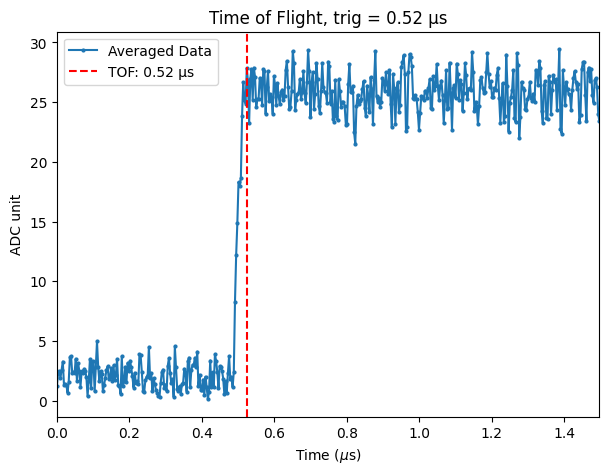

Data saved to D:\Labber_Data\Jay\purcell_tmon\2026\03\Data_0304\s001_tof_Q2_001


In [19]:
from qick_workspace.newscrip.s001_time_of_flight import TOF

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    {
        "res_freq_ge": 6862,
        "ro_length": 1.5,
        "res_legnth": 0.5,
        "res_gain_ge": 1,
        "res_ch": 0,
    }
)

tof = TOF(soc, soccfg, run_cfg)
tof.run(100)
tof.saveLabber(qubit)


In [35]:
config_all.update("trig_time", 0.49, q_index=qubit)

# YOKO Setting

In [ ]:
# from qick_workspace.tools.YOKOGS200 import YOKOGS200
# import pyvisa

# rm = pyvisa.ResourceManager()
# yoko_connect = "USB0::0x0B21::0x0039::90ZB35281::INSTR"
# yoko = YOKOGS200(yoko_connect, rm)

# yoko.OutputOn()
# yoko.OutputOff()

## Current mode

In [8]:
# yoko.SetMode("current")
# yokocurrent = 1 * 1e-3
# yoko.SetCurrent(yokocurrent)
# yoko.GetValue()

## Voltage mode

In [ ]:
# yoko.SetMode("voltage")
# yoko_value = -12.6
# yoko.SetVoltage(yoko_value, _rampstep=1e-2)
# print(yoko.GetValue())
# yoko_value = yoko.GetValue()

# GE State

## Resonator OneTone

c:\Users\cluster\Desktop\SQC_soc-dev_mux\qick_workspace\tools\abcd_rf_fit\abcd_rf_fit.py:187: UserWarning: Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False
  warnings.warn("Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False", UserWarning)


{'Fres(GHz)': np.float64(6.8118),
 'Qi': -38334,
 'Ql': 1176,
 'absQc': 1141,
 'κ(MHz)': np.float64(5.79)}


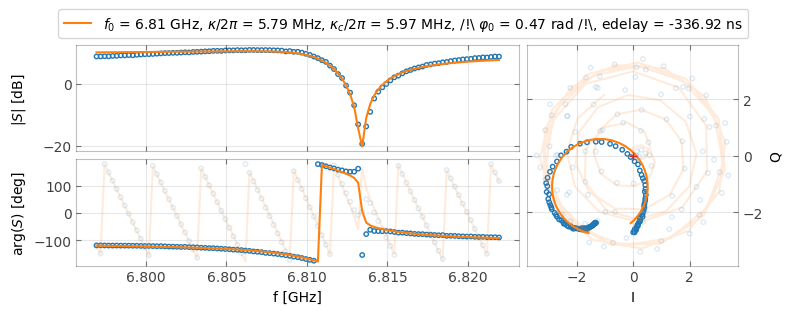

In [4]:
from qick_workspace.newscrip.s002_res_spec_ge import ResonatorSpec

START_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] - 15 # [MHz]
STOP_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] + 10  # [MHz]


STEPS = 101

config_all.update("res.res_gain_ge", 0.2, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("relax_delay", 0),
    ]
)

onetone = ResonatorSpec(soc, soccfg, run_cfg)
fres = onetone.run(py_avg=10, solve_type="hm")
## update value ##
config_all.update("res.res_freq_ge", round(fres[0] / 1e6, 4), q_index=qubit)
# onetone.saveLabber(qubit, yoko_value=None, config_all=config_all)

## OneTone PunchOut

In [193]:
from qick_workspace.newscrip.s002b_res_punchout_ge import Punchout

START_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] - 20  # [MHz]
STOP_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] + 20  # [MHz]
STEPS_freq = 201

START_gain = 0.1
STOP_gain = 1
STEPS_gain = 11

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("f_steps", STEPS_freq),
        ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("g_steps", STEPS_gain),
        ("res_gain_ge", QickSweep1D("gainloop", START_gain, STOP_gain)),
    ]
)
punchout = Punchout(soc, soccfg, run_cfg)
punchout.run(py_avg=50)
punchout.saveLabber(qubit, config_all=config_all)

Experiment interrupted at 13 averages. Fit is based on partial data.
Data saved to D:\Labber_Data\Jay\purcell_tmon\2026\03\Data_0304\s002b_res_ge_punchout_Q3_001


## Qubit Spectrum ge

Experiment interrupted at 12 averages. Fit is based on partial data.


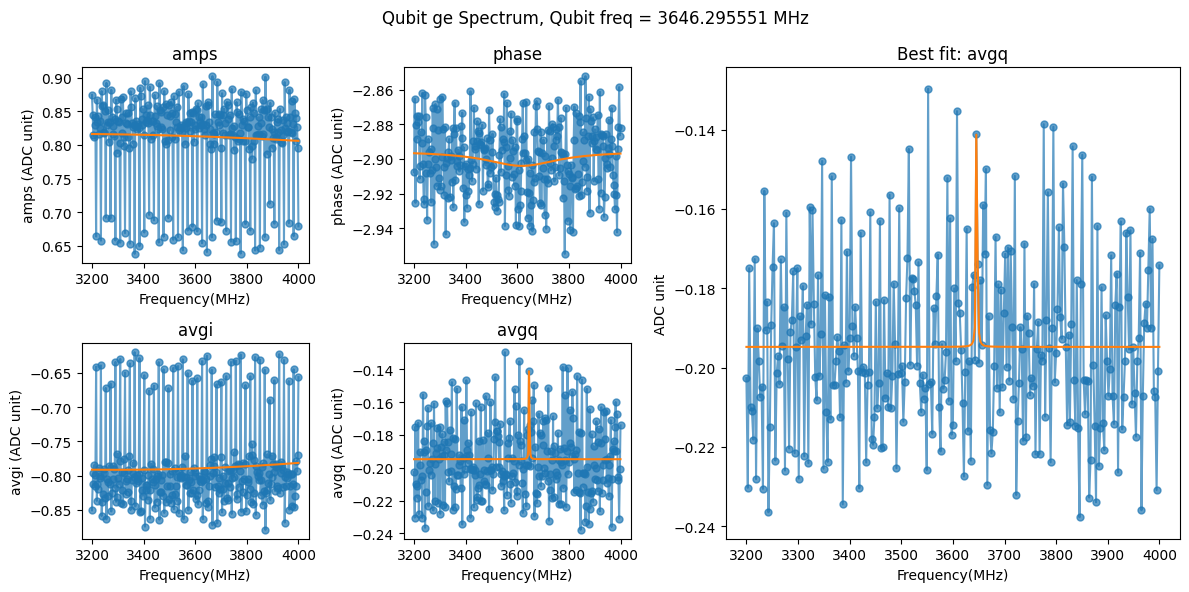

In [7]:
from qick_workspace.newscrip.s003_qubit_spec_ge import QubitSpec

center = 3600
SPAN = 400
START_FREQ = center - SPAN  # [MHz]
STOP_FREQ = center + SPAN  # [MHz]
STEPS = 301


run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("qb_mixer", center),
        ("qb_gain_ge", 0.5),
        ("qb_flat_top_length_ge", 5),
        ("relax_delay", 2),
        ("nqz_qb", 1),
    ]
)

spectrum_ge = QubitSpec(soc, soccfg, run_cfg)
f_ge = spectrum_ge.run(100)
config_all.update("qb.qb_freq_ge", f_ge, q_index=qubit)
config_all.update("qb.qb_mixer", f_ge, q_index=qubit)
# spectrum_ge.saveLabber(qubit, config_all=config_all)


## Time Rabi ge

In [ ]:
from qick_workspace.newscrip.s004_time_rabi_ge import TimeRabi

time_array = np.linspace(0.01, 1, 101)

config_all.update("qb.sigma", 0.05, q_index=qubit)
config_all.update("relax_delay", 30, q_index=qubit)

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("cooling", False),
        ("qb_gain_ge", 0.5),

    ]
)

Trabi = TimeRabi(soc, soccfg, run_cfg)
a, b = Trabi.run(20, time_axis=time_array)
# Trabi.saveLabber(qubit, yoko_value=yoko_value)

Traceback (most recent call last):
  File "c:\Users\cluster\anaconda3\envs\qick2env\lib\site-packages\IPython\core\interactiveshell.py", line 3550, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\cluster\AppData\Local\Temp\ipykernel_28608\1042590672.py", line 17, in <module>
    a, b = Trabi.run(20, time_axis=time_array)
  File "c:\Users\cluster\Desktop\SQC_soc-dev_mux\qick_workspace\newscrip\base_experiment.py", line 126, in run
    prog = self._create_program()
  File "c:\Users\cluster\Desktop\SQC_soc-dev_mux\qick_workspace\newscrip\s004_time_rabi_ge.py", line 44, in _create_program
    return TimeRabiProgram(
  File "c:\Users\cluster\anaconda3\envs\qick2env\lib\site-packages\qick\asm_v2.py", line 2733, in __init__
    self.compile()
  File "c:\Users\cluster\anaconda3\envs\qick2env\lib\site-packages\qick\asm_v2.py", line 2750, in compile
    self.make_program()
  File "c:\Users\cluster\anaconda3\envs\qick2env\lib\site-packages\qick\asm_v2.py", line 

## Power Rabi ge

Experiment interrupted at 30 averages. Fit is based on partial data.
Data saved to D:\Labber_Data\Jay\purcell_tmon\2026\03\Data_0304\s005_power_rabi_ge_Q1_003


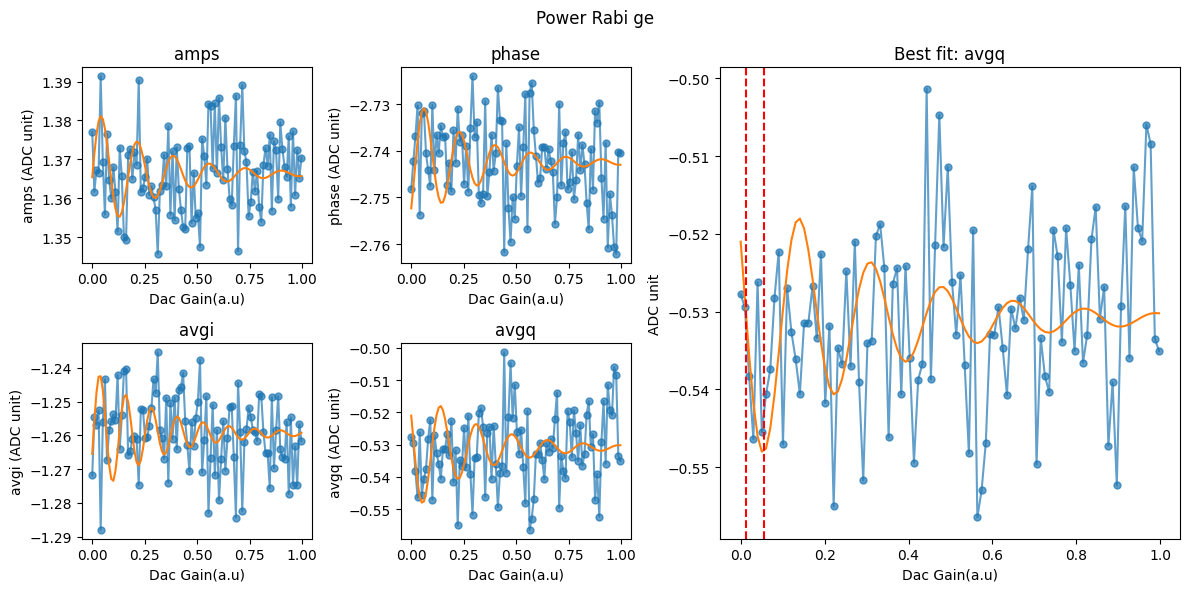

In [202]:
from qick_workspace.newscrip.s005_power_rabi_ge import PowerRabi

START_GAIN = 0.0  # [DAC units]
STOP_GAIN = 1  # [DAC units]
STEPS = 100

config_all.update("qb.sigma_ge", 0.1, q_index=qubit)
config_all.update("qb.nqz_qb", 1, q_index=qubit)
config_all.update("relax_delay", 100, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_gain_ge", QickSweep1D("gainloop", START_GAIN, STOP_GAIN)),
        ("cooling", False),
    ]
)

prabi = PowerRabi(soc, soccfg, run_cfg)
pi_gain, pi2_gain = prabi.run(100)
config_all.update("qb.pi_gain_ge", pi_gain, q_index=qubit)
config_all.update("qb.pi2_gain_ge", pi2_gain, q_index=qubit)
prabi.saveLabber(qubit, config_all=config_all)

## Amplified Amplitude Error (AAE)

In [ ]:
from qick_workspace.newscrip.s005a_AAE import AAE

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("AAE", "pi2"),
        ("pi2_gain_ge", 0.43164),
    ]
)

aae = AAE(soc, soccfg, run_cfg)
aae.run(20, liveplot=True, iteration=15)

## Ramsey ge

Experiment interrupted at 7 averages. Fit is based on partial data.


array([ 0.12166992,  4.32660437, 90.00439902,  1.89113153,  1.35170357])

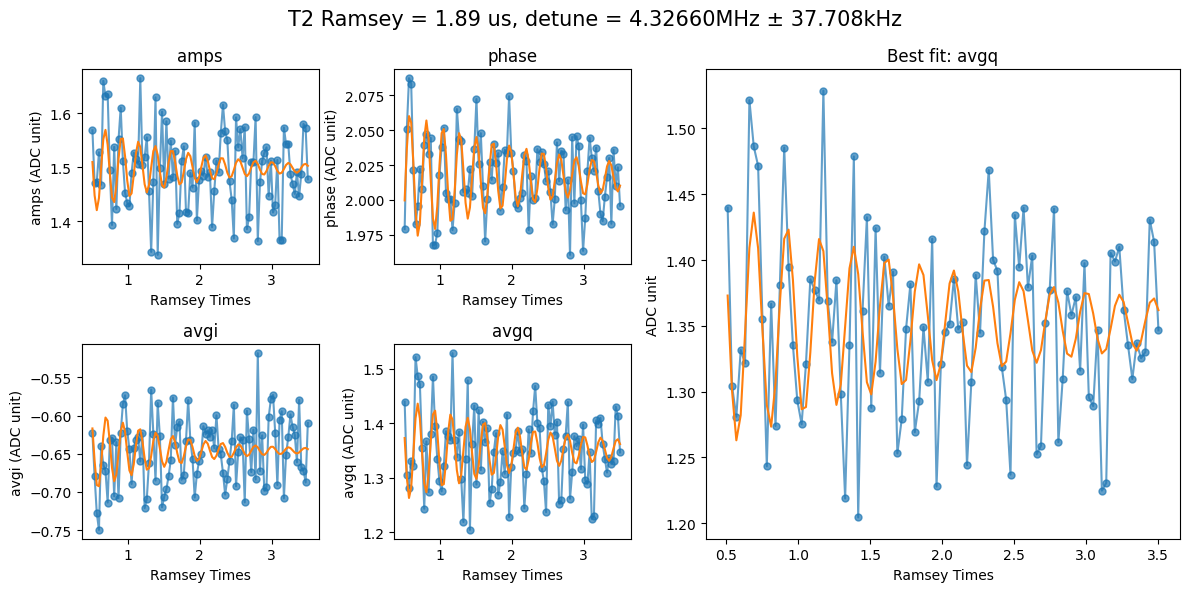

In [ ]:
from qick_workspace.newscrip.s006_Ramsey_ge import Ramsey

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 3  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        ("ramsey_freq", 2),
    ]
)

t2r = Ramsey(soc, soccfg, run_cfg)
t2r.run(50)
# t2r.saveLabber(qubit, yoko_value=yoko_value)

In [180]:
config_all.update("qb.qb_freq_ge", t2r.correct_detune(), qubit)

over detune 2.07591MHz


## Spin Echo ge

Experiment interrupted at 14 averages. Fit is based on partial data.


array([ 4.70735051e-02,  2.30014376e+01,  2.77282688e+02,  1.95255910e+00,
       -6.49388771e-01])

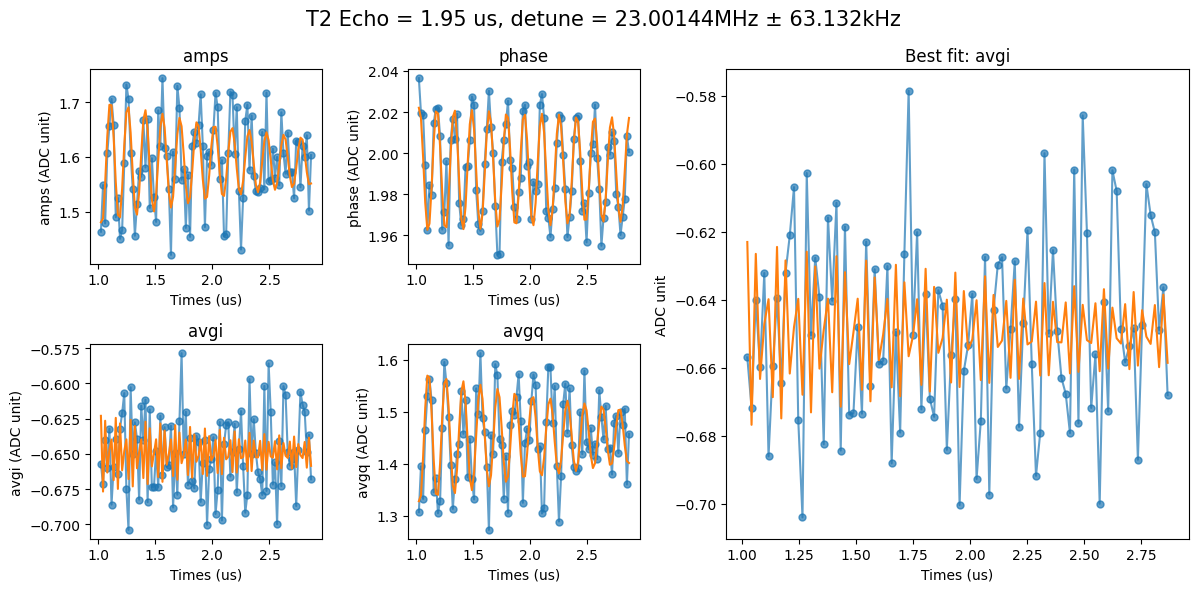

In [188]:
from qick_workspace.newscrip.s007_SpinEcho_ge import SpinEcho

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 2  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        ("ramsey_freq", 3),
        ("cooling", False),
    ]
)

t2e = SpinEcho(soc, soccfg, run_cfg)
t2e.run(20)
# t2e.saveLabber(qubit, yoko_value=yoko_value)

## T1 ge

Experiment interrupted at 15 averages. Fit is based on partial data.
Data saved to D:\Labber_Data\Jay\purcell_tmon\2026\03\Data_0303\s008_T1_ge_Q2_002


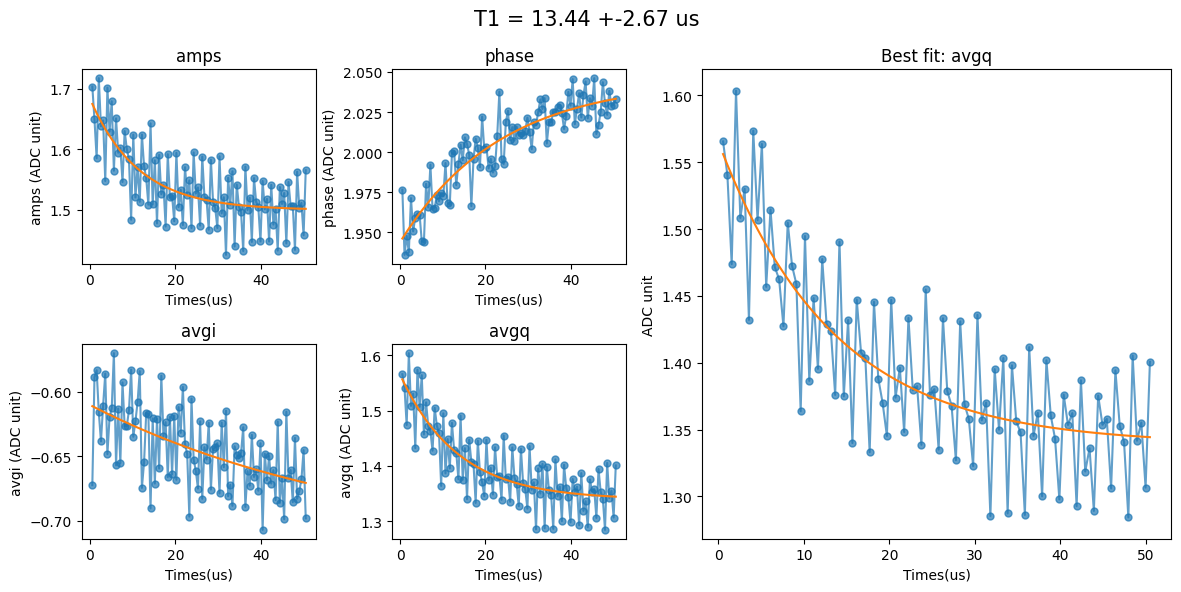

In [189]:
from qick_workspace.newscrip.s008_T1_ge import T1

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 50  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        ("relax_delay", 50),
        # ("cooling", False),
    ]
)

t1 = T1(soc, soccfg, run_cfg)
t1.run(50)
t1.saveLabber(qubit, config_all=config_all)

## Single Shot

In [190]:
from qick_workspace.newscrip.s000_SingleShot_prog import SingleShot_gef

run_cfg = config_all.get_qubit(qubit)

run_cfg["ro_length"] = 1
run_cfg["res_gain_ge"] = 0.7

SHOT = 5000
ssh = SingleShot_gef(soc, soccfg, run_cfg)
ssh.run(SHOT, shot_f=False)
ssh.plot(fid_avg=True, verbose=True, fit=True)

Traceback (most recent call last):
  File "c:\Users\cluster\anaconda3\envs\qick2env\lib\site-packages\IPython\core\interactiveshell.py", line 3550, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\cluster\AppData\Local\Temp\ipykernel_28608\3429243852.py", line 10, in <module>
    ssh.run(SHOT, shot_f=False)
  File "c:\Users\cluster\Desktop\SQC_soc-dev_mux\qick_workspace\newscrip\s000_SingleShot_prog.py", line 101, in run
    prog = SingleShotProgram_gef(
  File "c:\Users\cluster\anaconda3\envs\qick2env\lib\site-packages\qick\asm_v2.py", line 2733, in __init__
    self.compile()
  File "c:\Users\cluster\anaconda3\envs\qick2env\lib\site-packages\qick\asm_v2.py", line 2750, in compile
    self.make_program()
  File "c:\Users\cluster\anaconda3\envs\qick2env\lib\site-packages\qick\asm_v2.py", line 2820, in make_program
    self._initialize(self.cfg)
  File "c:\Users\cluster\Desktop\SQC_soc-dev_mux\qick_workspace\newscrip\s000_SingleShot_prog.py", line 57, i

# EF State

## Resonator OneTone ef

In [ ]:
from qick_workspace.newscrip.s009_res_spec_ef import ResonatorSpec_ef

START_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] - 10  # [MHz]
STOP_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] + 10  # [MHz]
STEPS = 101

config_all.update("res.res_gain_ge", 0.2, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("relax_delay", 1),
    ]
)

onetone_ef = ResonatorSpec_ef(soc, soccfg, run_cfg)
fres = onetone_ef.run(py_avg=20, solve_type="hm")
## update value ##
config_all.update("res.res_freq_ge", round(fres[0] / 1e6, 4), q_index=qubit)
# onetone_ef.saveLabber(qubit, yoko_value=yoko_value)

## Qubit Spectrum ef

In [ ]:
from qick_workspace.newscrip.s010_qubit_spec_ef import QubitSpec_ef

center = 3000
SPAN = 100
START_FREQ = center - SPAN  # [MHz]
STOP_FREQ = center + SPAN  # [MHz]
STEPS = 201

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_freq_ef", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("qb_gain_ef", 0.1),
        ("qb_length_ef", 0.5),
        ("relax_delay", 50),
        ("qb_ch_ef", 2),
        ("ro_length", 1),
    ]
)

spectrum_ef = QubitSpec_ef(soc, soccfg, run_cfg)
f_ef = spectrum_ef.run(20)
config_all.update("qb.qb_freq_ef", f_ef, q_index=qubit)
config_all.update("qb.qb_mixer_ef", f_ef, q_index=qubit)
# spectrum_ef.saveLabber(qubit, yoko_value=yoko_value)

## Power Rabi ef

In [ ]:
from qick_workspace.newscrip.s011_power_rabi_ef import PowerRabi_ef

START_GAIN = 0.0  # [DAC units]
STOP_GAIN = 1  # [DAC units]
STEPS = 100

config_all.update("qb.sigma_ef", 0.02, q_index=qubit)
config_all.update("relax_delay", 30, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_gain_ef", QickSweep1D("gainloop", START_GAIN, STOP_GAIN)),
    ]
)

prabi_ef = PowerRabi_ef(soc, soccfg, run_cfg)
pi_gain, pi2_gain = prabi_ef.run(10)
config_all.update("qb.pi_gain_ef", pi_gain, q_index=qubit)
config_all.update("qb.pi2_gain_ef", pi2_gain, q_index=qubit)
# prabi_ef.saveLabber(qubit, yoko_value=yoko_value)

## Ramsey ef

In [ ]:
from qick_workspace.newscrip.s012_Ramsey_ef import Ramsey_ef

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 1  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        ("ramsey_freq", 5),
        ("ro_length", 0.3),
    ]
)

t2r_ef = Ramsey_ef(soc, soccfg, run_cfg)
t2r_ef.run(10)
# t2r_ef.saveLabber(qubit, yoko_value=None)

In [ ]:
config_all.update("qb.qb_freq_ef", t2r_ef.correct_detune(), qubit)

## T1 ef

In [ ]:
from qick_workspace.newscrip.s013_T1_ef import T1_ef

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 50  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        ("relax_delay", 50),
        ("cooling", False),
    ]
)

t1_ef = T1_ef(soc, soccfg, run_cfg)
t1_ef.run(50)
# t1_ef.saveLabber(qubit, yoko_value=yoko_value)

## Single Shot gef

In [ ]:
from qick_workspace.newscrip.s000_SingleShot_prog import SingleShot_gef

run_cfg = config_all.get_qubit(qubit)

run_cfg["ro_length"] = 0.4
run_cfg["res_gain_ge"] = 0.17341
run_cfg["res_freq_ge"] = 5352.28064
SHOT = 5000
ssh = SingleShot_gef(soc, soccfg, run_cfg)
ssh.run(SHOT, shot_f=True)
ssh.plot(fid_avg=True, verbose=True, fit=False)

# AllXY

In [ ]:
from qick_workspace.newscrip.s014_AllXY import AllXY

run_cfg = config_all.get_qubit(qubit)

allxy = AllXY(soc, soccfg, run_cfg)
allxy.run(10)
allxy.plot()

# State Tomography

In [ ]:
from qick_workspace.newscrip.s016_state_tomography import Tomography

pyavg = 10

run_cfg = config_all.get_qubit(qubit)

tomo = Tomography(soc, soccfg, run_cfg)

tomo.run(py_avg=pyavg, prep_pulse_name="x180")

tomo.plot(plot_type="2d", qb_idx=3)
tomo.plot(plot_type="3d", qb_idx=3)

# Randomized Benchmarking

In [ ]:
from qick_workspace.newscrip.s015_Single_qubit_RB import RandomizedBenchmarking

run_cfg = config_all.get_qubit(qubit)

py_avg = 1
max_circuit_depth = 50
delta_clifford = 5
number_sample = 10

all_rb_results = []

print("\n--- Running Standard RB (Ref) ---")
rb_exp_ref = RandomizedBenchmarking(soc, soccfg, run_cfg)
rb_exp_ref.run(
    py_avg=py_avg,
    max_circuit_depth=max_circuit_depth,
    delta_clifford=delta_clifford,
    number_sample=number_sample,
    interleaved_gate=None,
)
rb_exp_ref.plot(label="Ref")

all_rb_results.append(rb_exp_ref)

## Interleaved RB

In [ ]:
# interleaved_gates_to_test = ["X", "X/2", "-X/2", "Y", "Y/2", "-Y/2"]
interleaved_gates_to_test = ["X", "X/2", "Y", "Y/2"]

for gate in interleaved_gates_to_test:
    print(f"\n--- Running Interleaved RB ({gate}) ---")
    rb_exp_irb = RandomizedBenchmarking(soc, soccfg, run_cfg)
    rb_exp_irb.run(
        py_avg=py_avg,
        max_circuit_depth=max_circuit_depth,
        delta_clifford=delta_clifford,
        number_sample=number_sample,
        interleaved_gate=gate,
    )
    all_rb_results.append(rb_exp_irb)